In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split

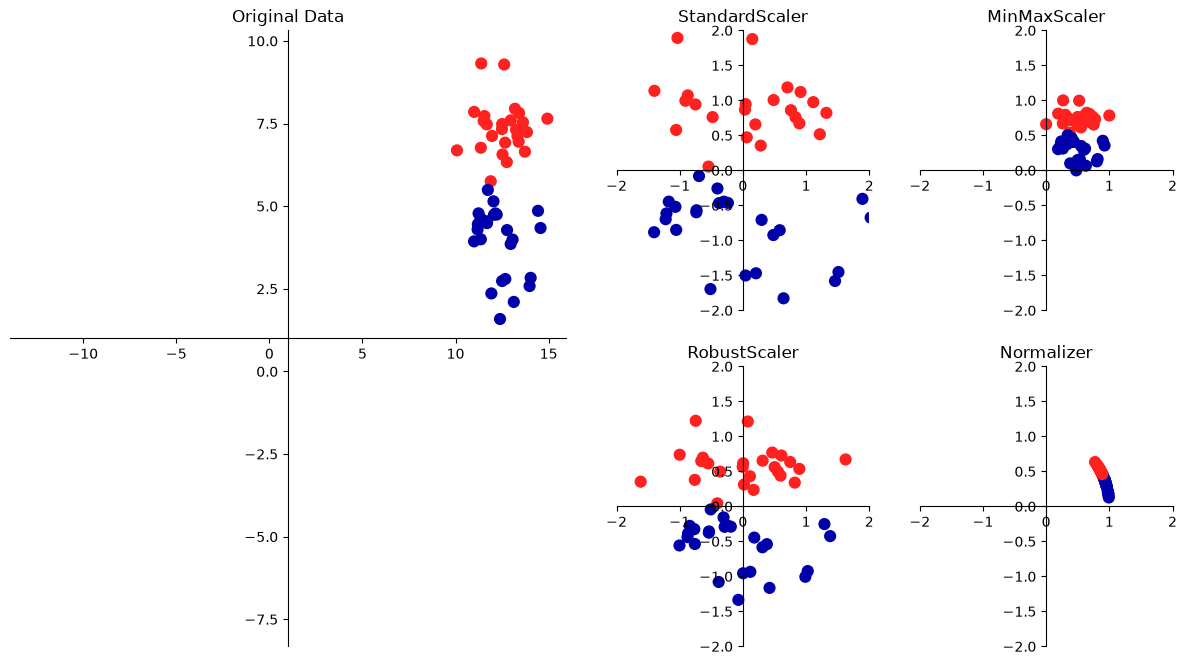

In [2]:
#データセットに対する様々なスケール変換と前処理結果

# StandardScaler
# 各特徴量を「平均0・分散1」になるように変換する
# 平均値と標準偏差を使うため、外れ値の影響を受けやすい
# ※ 値が0～1などの一定範囲に収まるわけではない

# MinMaxScaler
# 各特徴量の最小値を0、最大値を1に変換する
# 基本的に学習データを0～1の範囲に収める
# 最大値・最小値を使うため、外れ値の影響を受けやすい

# RobustScaler
# 各特徴量を「中央値0」を基準にスケーリングする
# 中央値と四分位範囲(IQR)を使うため、外れ値の影響を受けにくい
# ※ 値が一定範囲に収まるわけではない

# Normalizer
# 特徴量ごとではなく「1つのデータ（1行）」ごとに変換する
# 各データのベクトルの長さ（ノルム）を1にする
# データの方向を重視したい場合などに使う

mglearn.plots.plot_scaling()

**データ変換の適用**

In [3]:
#cancerデータセットをMINMAXScalerでスケーリングしてみる

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(
    cancer.data, 
    cancer.target, 
    random_state=0
)

print("x_train.shape: {}".format(x_train.shape))
print("x_test.shape: {}".format(x_test.shape))

x_train.shape: (426, 30)
x_test.shape: (143, 30)


In [4]:
from sklearn.preprocessing import MinMaxScaler

scalar = MinMaxScaler()

#fitメソッドで学習データの最大値・最小値を計算する
#x_testは使わない
scalar.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](30,)","[ 28.11, 33.81,188.5 ,..., 0.29, 0.66, 0.21]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](30,)","[ 6.98, 9.71,43.79,..., 0. , 0.16, 0.06]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](30,)","[ 21.13, 24.1 ,144.71,..., 0.29, 0.51, 0.15]"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](30,)","[-0.33,-0.4 ,-0.3 ,..., 0. ,-0.31,-0.36]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,426
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](30,)","[0.05,0.04,0.01,...,3.44,1.97,6.56]"


In [9]:
#データの変換
x_train_scaled = scalar.transform(x_train)

#スケール変換の前後のデータ特性をプリント
print("transformed shape:{}".format(x_train_scaled.shape))
print("per-feature minimum before scaling:\n {}".format(x_train.min(axis=0)))
print("per-feature maximum before scaling:\n {}".format(x_train.max(axis=0)))
print("per-feature minimum after scaling:\n {}".format(x_train_scaled.min(axis=0)))
print("per-feature maximum after scaling:\n {}".format(x_train_scaled.max(axis=0)))

transformed shape:(426, 30)
per-feature minimum before scaling:
 [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.263e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 4.996e-02 1.115e-01 3.628e-01 7.570e-01 7.228e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 7.882e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.565e-01 5.504e-02]
per-feature maximum before scaling:
 [2.811e+01 3.381e+01 1.885e+02 2.501e+03 1.447e-01 3.114e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 2.333e-02 1.064e-01 3.960e-01 5.279e-02 6.146e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.903e-01
 6.638e-01 2.075e-01]
per-feature minimum after scaling:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
per-feature maximum after scaling:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [ ]:
#SVMをスケール変換されたデータに適用するには、テストデータも同じスケール変換を行う必要がある

x_test_scaled = scalar.transform(x_test)

#最大値と最小値が0～1の範囲に収まっていない
#これは、学習データの最大値・最小値を使ってスケール変換しているため
#重要なのは、学習データとテストデータのスケールが同じであること
print("transformed shape:{}".format(x_test_scaled.shape))
print("per-feature minimum after scaling:\n {}".format(x_test_scaled.min(axis=0)))
print("per-feature maximum after scaling:\n {}".format(x_test_scaled.max(axis=0)))

transformed shape:(143, 30)
per-feature minimum after scaling:
 [ 0.03540158  0.04190871  0.02895446  0.01497349  0.14260888  0.04999658
  0.          0.          0.07222222  0.00589722  0.00105015 -0.00057494
  0.00067851 -0.0007963   0.05148726  0.01434497  0.          0.
  0.04195752  0.01113138  0.03678406  0.01252665  0.03366702  0.01400904
  0.08531995  0.01833687  0.          0.          0.00749064  0.02367834]
per-feature maximum after scaling:
 [0.76809125 1.22697095 0.75813696 0.64750795 1.20310633 1.11643038
 0.99906279 0.90606362 0.93232323 0.94903117 0.45573058 0.72623944
 0.48593507 0.31641282 1.36082713 1.2784499  0.36313131 0.77476795
 1.32643996 0.72672498 0.82106012 0.87553305 0.77887345 0.67803775
 0.78603975 0.87843331 0.93450479 1.0024113  0.76384782 0.58743277]


C:\Users\seita\AppData\Local\Temp\ipykernel_18484\2187674215.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[0].scatter(X_train[:, 0], X_train[:, 1], c=mglearn.cm2(0), label="Training set", s=60)
C:\Users\seita\AppData\Local\Temp\ipykernel_18484\2187674215.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[0].scatter(X_test[:, 0], X_test[:, 1], marker='^', c=mglearn.cm2(1), label="Test set", s=60)
C:\Users\sei

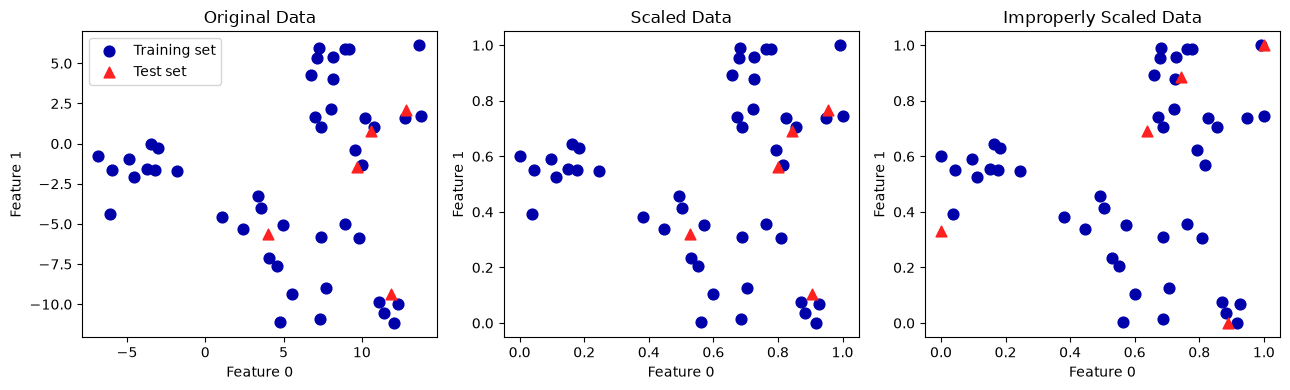

In [11]:
#もしテストセットの最小値とレンジを使うと何が起こるのかを示す
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)
X_train, X_test = train_test_split(X, random_state=5, test_size=.1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=mglearn.cm2(0), label="Training set", s=60)
axes[0].scatter(X_test[:, 0], X_test[:, 1], marker='^', c=mglearn.cm2(1), label="Test set", s=60)
axes[0].legend(loc='upper left')
axes[0].set_title("Original Data")

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

axes[1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=mglearn.cm2(0), label="Training set", s=60)
axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], marker='^', c=mglearn.cm2(1), label="Test set", s=60)
axes[1].set_title("Scaled Data")

# テストセットを訓練セットとは別にスケール変換
# 実際にはしてはいけない
test_scaler = MinMaxScaler()
test_scaler.fit(X_test)
X_test_scaled_badly = test_scaler.transform(X_test)

axes[2].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=mglearn.cm2(0), label="training set", s=60)
axes[2].scatter(X_test_scaled_badly[:, 0], X_test_scaled_badly[:, 1], marker='^', c=mglearn.cm2(1), label="test set", s=60)
axes[2].set_title("Improperly Scaled Data")

for ax in axes:
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
fig.tight_layout()

plt.show()

**教師あり学習における前処理の効果**

In [13]:
from sklearn.svm import SVC
x_train, x_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=0
)

#Cは正則化パラメータで、Cが大きいほど誤分類を許さないように学習する
#gamma = "auto"にあえてしているのはスケール変換の影響を見やすくするため
svc = SVC(C=100,gamma="auto")

#比較のため、スケール変換前のデータで学習
svc.fit(x_train, y_train)

print("Test set accuracy: {:.2f}".format(svc.score(x_test, y_test)))

Test set accuracy: 0.63


In [ ]:
#transformメソッドで学習データを変換する
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

svc.fit(x_train_scaled, y_train)

print("Test set accuracy: {:.2f}".format(svc.score(x_test_scaled, y_test)))

Test set accuracy: 0.97
